# Анализ игр Steam: от API до SQLite и аналитических выводов

## О проекте

Проект показывает полный аналитический цикл: сбор метаданных через SteamSpy и Steam Store API, аудит качества, очистку, нормализацию many-to-many данных в SQLite и анализ с помощью SQL и Python.

### Аналитические вопросы

1. Как различается распределение числа рекомендаций у бесплатных и платных игр в этом snapshot?
2. Сохраняется ли различие внутри сопоставимых периодов релиза?
3. Как различается цена платных игр в наиболее представленных жанрах?
4. Как связаны подтверждённая USD-цена и число рекомендаций у платных игр?

### Важные оговорки

- Выборка построена по популярным приложениям SteamSpy и не является случайной выборкой всего каталога Steam.
- `recommendations` — накопительный показатель и не равен продажам или оценке качества.
- Метаданные/рекомендации и цены собраны в разные моменты. Цена отражает регион США (`cc='us'`) на дату проверки, а не историческую цену.
- Анализ описательный: найденные связи не доказывают причинность.

## 1. Настройка окружения

Ноутбук запускается сверху вниз. По умолчанию используются сохранённые snapshot-файлы из `data/`, поэтому повторные API-запросы не нужны. Очищенный CSV и SQLite создаются в `artifacts/`, а графики — в `images/`.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import ast
import json
import sqlite3
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import Markdown, display

pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-whitegrid')


def find_project_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'steam_games_raw.csv').exists():
            return candidate
    raise FileNotFoundError('Project root with data/steam_games_raw.csv was not found.')


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / 'data'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
IMAGES_DIR = PROJECT_ROOT / 'images'
ARTIFACTS_DIR.mkdir(exist_ok=True)
IMAGES_DIR.mkdir(exist_ok=True)

RAW_PATH = DATA_DIR / 'steam_games_raw.csv'
PRICE_CACHE_PATH = DATA_DIR / 'steam_games_prices_us.csv'
CLEAN_PATH = ARTIFACTS_DIR / 'steam_games_clean.csv'
DB_PATH = ARTIFACTS_DIR / 'steam_games.db'

RUN_COLLECTION = False
REFRESH_PRICES = False
N_APPS = 1_000
REQUEST_DELAY_SECONDS = 1.0

## 2. Сбор данных и воспроизводимые snapshot-файлы

Список `appid` берётся из SteamSpy, а метаданные — из Steam Store API. Проверка цен выполняется отдельно через Store API с `cc='us'` и `l='english'` и сохраняется в компактный кэш `steam_games_prices_us.csv`.

Для платных игр в анализ попадает только цена с явно подтверждённой валютой `USD`. Если API не вернул цену, сохраняется `NaN`; это значение не подменяется нулём. Исходная колонка `price` из старой выгрузки сохраняется как `price_original` исключительно для аудита и не участвует в расчётах.

> Оба переключателя ниже по умолчанию выключены. Их включение обращается к внешним API и может занять 20–30 минут. Повторный запуск способен дать другой snapshot, потому что каталог, рекомендации и цены меняются.

In [2]:
def request_json(session, url, *, params=None, timeout=20, attempts=3):
    for attempt in range(attempts):
        try:
            response = session.get(url, params=params, timeout=timeout)
            response.raise_for_status()
            return response.json()
        except (requests.RequestException, ValueError):
            if attempt == attempts - 1:
                return None
            time.sleep(2 ** attempt)


def fetch_appids(session, page=0):
    payload = request_json(
        session,
        'https://steamspy.com/api.php',
        params={'request': 'all', 'page': page},
    )
    if not isinstance(payload, dict):
        raise RuntimeError('SteamSpy did not return an app dictionary.')
    return [int(appid) for appid in payload]


def fetch_store_game(session, appid):
    payload = request_json(
        session,
        'https://store.steampowered.com/api/appdetails',
        params={'appids': appid, 'cc': 'us', 'l': 'english'},
    )
    app_payload = payload.get(str(appid), {}) if isinstance(payload, dict) else {}
    if not app_payload.get('success'):
        return None
    game = app_payload.get('data', {})
    return game if game.get('type') == 'game' else None


def extract_price_record(appid, game, checked_at):
    if game is None:
        return {
            'appid': appid, 'price': None, 'currency': None,
            'is_free_now': None, 'price_checked_at': checked_at,
        }

    is_free = bool(game.get('is_free', False))
    price_overview = game.get('price_overview') or {}
    currency = price_overview.get('currency')
    price_minor = price_overview.get('final')
    price = 0.0 if is_free else (
        price_minor / 100 if currency == 'USD' and price_minor is not None else None
    )
    return {
        'appid': appid, 'price': price, 'currency': currency,
        'is_free_now': is_free, 'price_checked_at': checked_at,
    }


def collect_snapshot(n_apps=N_APPS, delay=REQUEST_DELAY_SECONDS):
    records = []
    prices = []
    checked_at = datetime.now(timezone.utc).isoformat()

    with requests.Session() as session:
        appids = fetch_appids(session)[:n_apps]
        for position, appid in enumerate(appids, start=1):
            game = fetch_store_game(session, appid)
            if game is not None:
                release = game.get('release_date') or {}
                recommendations = game.get('recommendations') or {}
                platforms = game.get('platforms') or {}
                records.append({
                    'appid': appid,
                    'name': game.get('name'),
                    'is_free': bool(game.get('is_free', False)),
                    'required_age': game.get('required_age'),
                    'developers': game.get('developers') or [],
                    'publishers': game.get('publishers') or [],
                    'genres': [item.get('description') for item in game.get('genres', [])],
                    'recommendations': recommendations.get('total'),
                    'release_date': release.get('date'),
                    'windows': platforms.get('windows'),
                    'mac': platforms.get('mac'),
                    'linux': platforms.get('linux'),
                })
                prices.append(extract_price_record(appid, game, checked_at))
            if position % 50 == 0:
                print(f'Processed {position}/{len(appids)} appids')
            time.sleep(delay)

    snapshot = pd.DataFrame(records)
    for column in ['developers', 'publishers', 'genres']:
        snapshot[column] = snapshot[column].apply(
            lambda value: json.dumps(value, ensure_ascii=False)
        )
    snapshot.to_csv(RAW_PATH, index=False)
    pd.DataFrame(prices).drop_duplicates('appid').to_csv(PRICE_CACHE_PATH, index=False)
    return snapshot


def refresh_prices(raw_path=RAW_PATH, delay=REQUEST_DELAY_SECONDS):
    snapshot = pd.read_csv(raw_path)
    appids = snapshot['appid'].dropna().astype(int).drop_duplicates().tolist()
    checked_at = datetime.now(timezone.utc).isoformat()
    price_records = []

    with requests.Session() as session:
        for position, appid in enumerate(appids, start=1):
            game = fetch_store_game(session, appid)
            price_records.append(extract_price_record(appid, game, checked_at))
            if position % 50 == 0:
                print(f'Refreshed {position}/{len(appids)} prices')
            time.sleep(delay)

    price_frame = pd.DataFrame(price_records)
    price_frame.to_csv(PRICE_CACHE_PATH, index=False)
    return price_frame


if RUN_COLLECTION:
    collected = collect_snapshot()
    print(f'Saved {len(collected)} game records and a USD price cache.')
elif REFRESH_PRICES:
    refreshed = refresh_prices()
    print(f'Refreshed prices for {refreshed.appid.nunique()} appids.')

### Загрузка snapshot

Raw-файл не перезаписывается во время анализа. Все преобразования выполняются в отдельном датафрейме. Кэш цен соединяется по `appid` только после удаления дублей.

In [3]:
for required_path in [RAW_PATH, PRICE_CACHE_PATH]:
    if not required_path.exists():
        raise FileNotFoundError(f'Required snapshot file not found: {required_path}')

df_raw = pd.read_csv(RAW_PATH)
prices_raw = pd.read_csv(PRICE_CACHE_PATH)
print(f'Raw metadata: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns')
print(f'Price cache: {prices_raw.shape[0]} rows × {prices_raw.shape[1]} columns')
df_raw.head()

Raw metadata: 913 rows × 13 columns
Price cache: 906 rows × 5 columns


,appid,name,is_free,required_age,developers,publishers,genres,recommendations,release_date,windows,mac,linux,price
0,730,Counter-Strike 2,True,0,['Valve'],['Valve'],"['Action', 'Free To Play']",5251179,"21 Aug, 2012",True,False,True,0.00
1,1172470,Apex Legends™,True,0,['Respawn'],['Electronic Arts'],"['Action', 'Adventure', 'Free To Play']",1580,"4 Nov, 2020",True,False,False,0.00
2,578080,PUBG: BATTLEGROUNDS,True,19,['PUBG Corporation'],"['KRAFTON, Inc.']","['Action', 'Adventure', 'Massively Multiplayer...",1763188,"21 Dec, 2017",True,False,False,0.00
3,1623730,Palworld,False,0,['Pocketpair'],['Pocketpair'],"['Action', 'Adventure', 'Indie', 'RPG']",407997,"9 Jul, 2026",True,False,False,20.29
4,440,Team Fortress 2,True,0,['Valve'],['Valve'],"['Action', 'Free To Play']",47800,"10 Oct, 2007",True,False,True,0.00


## 3. Проверка качества данных

Проверка проводится до изменений: схема, пропуски, уникальность `appid`, списковые поля, даты и цена/валюта. Отсутствие большого числа `NaN` само по себе не является доказательством качества: значения могли быть заменены на `0`, пустую строку или пустой список ещё при сборе.


In [4]:
expected_columns = {
    'appid', 'name', 'is_free', 'required_age', 'developers', 'publishers',
    'genres', 'recommendations', 'release_date', 'windows', 'mac', 'linux',
}
price_columns = {'appid', 'price', 'currency', 'is_free_now', 'price_checked_at'}
missing_columns = sorted(expected_columns - set(df_raw.columns))
missing_price_columns = sorted(price_columns - set(prices_raw.columns))
if missing_columns or missing_price_columns:
    raise ValueError(
        f'Missing metadata columns: {missing_columns}; '
        f'missing price-cache columns: {missing_price_columns}'
    )

quality_before = pd.DataFrame({
    'dtype': df_raw.dtypes.astype(str),
    'missing': df_raw.isna().sum(),
    'missing_pct': (df_raw.isna().mean() * 100).round(1),
    'unique': df_raw.nunique(dropna=True),
})
display(quality_before)


def raw_list_is_empty(value):
    if isinstance(value, list):
        return len(value) == 0
    if pd.isna(value) or str(value).strip() == '':
        return True
    for parser in (json.loads, ast.literal_eval):
        try:
            parsed = parser(value)
            return isinstance(parsed, list) and len(parsed) == 0
        except (ValueError, TypeError, SyntaxError, json.JSONDecodeError):
            continue
    return False


hidden_missing = {
    f'empty_{column}': int(df_raw[column].apply(raw_list_is_empty).sum())
    for column in ['developers', 'publishers', 'genres']
}
hidden_missing['empty_release_date'] = int(
    df_raw['release_date'].fillna('').astype(str).str.strip().eq('').sum()
)
hidden_missing['duplicate_appids'] = int(df_raw.duplicated('appid').sum())
pd.Series(hidden_missing, name='rows').to_frame()

,dtype,missing,missing_pct,unique
appid,int64,0,0.0,906
name,str,0,0.0,907
is_free,bool,0,0.0,2
required_age,int64,0,0.0,9
developers,str,0,0.0,651
publishers,str,0,0.0,465
genres,str,0,0.0,232
recommendations,int64,0,0.0,838
release_date,str,13,1.4,787
windows,bool,0,0.0,1


,rows
empty_developers,0
empty_publishers,3
empty_genres,4
empty_release_date,13
duplicate_appids,7


In [5]:
duplicate_mask = df_raw.duplicated(subset='appid', keep=False)
print('Duplicate rows by appid:', int(df_raw.duplicated(subset='appid').sum()))
df_raw.loc[duplicate_mask].sort_values('appid')


Duplicate rows by appid: 7


,appid,name,is_free,required_age,developers,publishers,genres,recommendations,release_date,windows,mac,linux,price
74,80,Counter-Strike: Condition Zero,False,0,['Valve'],['Valve'],['Action'],21411,"1 Mar, 2004",True,True,True,8.19
118,80,Counter-Strike: Condition Zero,False,0,['Valve'],['Valve'],['Action'],21411,"1 Mar, 2004",True,True,True,8.19
128,10180,Call of Duty®: Modern Warfare® 2 (2009),False,0,['Infinity Ward'],['Activision'],['Action'],35648,"11 Nov, 2009",True,True,False,19.99
199,10180,Call of Duty®: Modern Warfare® 2 (2009),False,0,['Infinity Ward'],['Activision'],['Action'],35647,"11 Nov, 2009",True,True,False,19.99
552,22330,The Elder Scrolls IV: Oblivion® Game of the Ye...,False,0,['Bethesda Game Studios®'],['Bethesda Softworks'],[],42901,"16 Jun, 2009",True,False,False,19.99
583,22330,The Elder Scrolls IV: Oblivion® Game of the Ye...,False,0,['Bethesda Game Studios'],['Bethesda Softworks'],['RPG'],42901,"16 Jun, 2009",True,False,False,14.99
292,34330,Total War: SHOGUN 2,False,0,"['CREATIVE ASSEMBLY', 'Feral Interactive (Mac)...","['SEGA', 'Feral Interactive (Mac)', 'Feral Int...",['Strategy'],37910,"14 Mar, 2011",True,True,True,29.99
392,34330,Total War: SHOGUN 2,False,0,['The Creative Assembly'],['SEGA'],[],37910,NaN,True,False,False,0.00
226,42680,Call of Duty®: Modern Warfare® 3 (2011),False,0,"['Infinity Ward', 'Sledgehammer Games']",['Activision'],['Action'],15491,"7 Nov, 2011",True,False,False,39.99
316,42680,Call of Duty®: Modern Warfare® 3 (2011),False,0,"['Infinity Ward', 'Sledgehammer Games']",['Activision'],['Action'],15491,"7 Nov, 2011",True,False,False,39.99


### Аудит цены и валюты

Цена из исходной выгрузки не имеет надёжно зафиксированной валюты. Она сохраняется как `price_original` для сравнения, но не используется ни в SQL, ни в Python-анализе. Рабочая цена берётся только из отдельного кэша, полученного с `cc='us'`.

In [6]:
if prices_raw['appid'].duplicated().any():
    raise ValueError('The price cache must contain no duplicate appids.')

prices_audit = prices_raw.copy()
prices_audit['price'] = pd.to_numeric(prices_audit['price'], errors='coerce')
prices_audit['currency'] = prices_audit['currency'].astype('string').str.strip().replace('', pd.NA)
prices_audit['is_free_now'] = prices_audit['is_free_now'].astype('boolean')

paid_price_mask = prices_audit['is_free_now'].eq(False)
price_audit = pd.Series({
    'cached_appids': prices_audit['appid'].nunique(),
    'missing_current_free_status': int(prices_audit['is_free_now'].isna().sum()),
    'paid_games': int(paid_price_mask.sum()),
    'paid_with_confirmed_usd_price': int(
        (paid_price_mask & prices_audit['price'].notna() & prices_audit['currency'].eq('USD')).sum()
    ),
    'paid_with_missing_price': int((paid_price_mask & prices_audit['price'].isna()).sum()),
    'paid_with_non_usd_currency': int(
        (paid_price_mask & prices_audit['currency'].notna() & ~prices_audit['currency'].eq('USD')).sum()
    ),
    'negative_prices': int(prices_audit['price'].lt(0).sum()),
    'maximum_confirmed_price_usd': prices_audit.loc[
        prices_audit['currency'].eq('USD'), 'price'
    ].max(),
})
price_audit.to_frame('value')

,value
cached_appids,906.00
missing_current_free_status,3.00
paid_games,767.00
paid_with_confirmed_usd_price,672.00
paid_with_missing_price,95.00
paid_with_non_usd_currency,0.00
negative_prices,0.00
maximum_confirmed_price_usd,59.99


## 4. Очистка и подготовка данных

Здесь выполняются только обоснованные преобразования:

- строковые представления списков возвращаются в списки;
- типы приводятся явно;
- дубликаты `appid` разрешаются по полноте записи;
- недоступные значения сохраняются как пропуски;
- перед преобразованием дат исправляются реально встречавшиеся локализованные фрагменты `авг.`, `г.` и `Mai`;
- даты преобразуются с `errors='coerce'`, а ошибки становятся видимыми в отчёте качества;
- будущие релизы отделяются от уже выпущенных игр.

Искусственная «грязь» в данные не добавляется.


In [7]:
def parse_list(value):
    if isinstance(value, list):
        return value
    if pd.isna(value) or str(value).strip() == '':
        return []
    for parser in (json.loads, ast.literal_eval):
        try:
            parsed = parser(value)
            return parsed if isinstance(parsed, list) else []
        except (ValueError, TypeError, SyntaxError, json.JSONDecodeError):
            continue
    return []


def to_boolean(series):
    if pd.api.types.is_bool_dtype(series):
        return series.astype('boolean')
    mapping = {
        'true': True, 'false': False, '1': True, '0': False,
        'yes': True, 'no': False,
    }
    return series.astype(str).str.strip().str.lower().map(mapping).astype('boolean')


df_clean = df_raw.rename(columns={'price': 'price_original'}).copy()
for column in ['developers', 'publishers', 'genres']:
    df_clean[column] = df_clean[column].apply(parse_list)
for column in ['is_free', 'windows', 'mac', 'linux']:
    df_clean[column] = to_boolean(df_clean[column])
for column in ['required_age', 'recommendations', 'price_original']:
    if column in df_clean.columns:
        df_clean[column] = pd.to_numeric(df_clean[column], errors='coerce')

df_clean['name'] = df_clean['name'].astype('string').str.strip().replace('', pd.NA)

In [8]:
date_text = (
    df_clean['release_date']
    .astype('string')
    .str.strip()
    .str.replace('авг.', 'Aug', regex=False)
    .str.replace('г.', '', regex=False)
    .str.replace('Mai', 'May', regex=False)
)
df_clean['release_date'] = pd.to_datetime(date_text, errors='coerce', format='mixed')
date_parse_failures = date_text.notna() & date_text.ne('') & df_clean['release_date'].isna()
print('Non-empty release dates that could not be parsed:', int(date_parse_failures.sum()))
if date_parse_failures.any():
    display(date_text.loc[date_parse_failures].value_counts().head(10).to_frame('rows'))

df_clean['completeness_score'] = (
    df_clean['name'].notna().astype(int)
    + df_clean['developers'].str.len().gt(0).astype(int)
    + df_clean['publishers'].str.len().gt(0).astype(int)
    + df_clean['genres'].str.len().gt(0).astype(int)
    + df_clean['release_date'].notna().astype(int)
    + df_clean['recommendations'].notna().astype(int)
)

rows_before_deduplication = len(df_clean)
df_clean = (
    df_clean
    .sort_values(
        ['appid', 'completeness_score', 'recommendations'],
        ascending=[True, False, False],
        na_position='last',
    )
    .drop_duplicates(subset='appid', keep='first')
    .drop(columns='completeness_score')
    .reset_index(drop=True)
)
print('Rows removed as duplicate appids:', rows_before_deduplication - len(df_clean))

price_frame = prices_audit.rename(columns={
    'price': 'price_usd',
    'currency': 'price_currency',
})
price_frame['price_checked_at'] = pd.to_datetime(
    price_frame['price_checked_at'], errors='coerce', utc=True
)
df_clean = df_clean.merge(price_frame, on='appid', how='left', validate='one_to_one')
df_clean['is_free_at_metadata_collection'] = df_clean.pop('is_free')
df_clean['is_free'] = df_clean['is_free_now'].fillna(
    df_clean['is_free_at_metadata_collection']
).astype('boolean')

Non-empty release dates that could not be parsed: 0
Rows removed as duplicate appids: 7


In [9]:
paid_mask = df_clean['is_free'].eq(False)
invalid_paid_currency = (
    paid_mask & df_clean['price_currency'].notna() & ~df_clean['price_currency'].eq('USD')
)
zero_paid_price = paid_mask & df_clean['price_usd'].eq(0)
negative_price = df_clean['price_usd'].lt(0)

if invalid_paid_currency.any():
    raise ValueError('Paid records with a non-USD currency remain in the snapshot.')
if negative_price.any():
    raise ValueError('Negative prices require investigation.')

df_clean.loc[zero_paid_price, 'price_usd'] = np.nan
print('Zero prices in paid games converted to missing:', int(zero_paid_price.sum()))

df_clean['release_year'] = df_clean['release_date'].dt.year.astype('Int64')
if df_clean['price_checked_at'].notna().any():
    reference_date = df_clean['price_checked_at'].max().tz_convert(None).normalize()
else:
    reference_date = pd.Timestamp.today().normalize()

df_analysis = df_clean.copy()
released_mask = (
    df_clean['release_date'].notna()
    & df_clean['release_date'].le(reference_date)
)
df_released = df_clean.loc[released_mask].copy()
df_released['age_years'] = (
    (reference_date - df_released['release_date']).dt.days / 365.25
).clip(lower=0)

print('Rows after preparation:', len(df_clean))
print('Released games with a parsed date:', len(df_released))
print('Price reference date:', reference_date.date())

Zero prices in paid games converted to missing: 0
Rows after preparation: 906
Released games with a parsed date: 894
Price reference date: 2026-10-04


In [10]:
unique_after = pd.Series({
    column: (
        df_clean[column].apply(tuple).nunique(dropna=True)
        if column in ['developers', 'publishers', 'genres']
        else df_clean[column].nunique(dropna=True)
    )
    for column in df_clean.columns
})

quality_after = pd.DataFrame({
    'dtype': df_clean.dtypes.astype(str),
    'missing': df_clean.isna().sum(),
    'missing_pct': (df_clean.isna().mean() * 100).round(1),
    'unique': unique_after,
})

validation_summary = pd.Series({
    'rows': len(df_clean),
    'unique_appids': df_clean['appid'].nunique(),
    'duplicate_appids': int(df_clean.duplicated('appid').sum()),
    'missing_release_dates': int(df_clean['release_date'].isna().sum()),
    'missing_recommendations': int(df_clean['recommendations'].isna().sum()),
    'missing_current_free_status': int(df_clean['is_free_now'].isna().sum()),
    'paid_games_without_confirmed_price': int(
        (paid_mask & df_clean['price_usd'].isna()).sum()
    ),
})

display(validation_summary.to_frame('value'))
quality_after

,value
rows,906
unique_appids,906
duplicate_appids,0
missing_release_dates,12
missing_recommendations,0
missing_current_free_status,3
paid_games_without_confirmed_price,97


,dtype,missing,missing_pct,unique
appid,int64,0,0.0,906
name,string,0,0.0,906
required_age,int64,0,0.0,9
developers,object,0,0.0,649
publishers,object,0,0.0,465
genres,object,0,0.0,232
recommendations,int64,0,0.0,837
release_date,datetime64[us],12,1.3,781
windows,boolean,0,0.0,1
mac,boolean,0,0.0,2


In [11]:
save_frame = df_clean.copy()
for column in ['developers', 'publishers', 'genres']:
    save_frame[column] = save_frame[column].apply(
        lambda value: json.dumps(value, ensure_ascii=False)
    )

save_frame.to_csv(CLEAN_PATH, index=False)
print(f'Clean dataset saved to {CLEAN_PATH.relative_to(PROJECT_ROOT)}')

Clean dataset saved to artifacts/steam_games_clean.csv


## 5. Нормализация данных в SQLite

Списковые поля вынесены в справочники и таблицы связей many-to-many:

- `games` — одна строка на игру;
- `genres`, `developers`, `publishers` — справочники;
- `game_genres`, `game_developers`, `game_publishers` — связи между играми и справочниками.

Это сохраняет все связи без дублирования основной информации об игре.


In [12]:
game_columns = [
    'appid', 'name', 'is_free', 'is_free_at_metadata_collection',
    'required_age', 'recommendations', 'release_date', 'release_year',
    'windows', 'mac', 'linux', 'price_usd', 'price_currency', 'price_checked_at',
]
games_table = df_clean[game_columns].copy()
games_table['release_date'] = games_table['release_date'].dt.strftime('%Y-%m-%d')
games_table['price_checked_at'] = games_table['price_checked_at'].astype('string')
for column in [
    'is_free', 'is_free_at_metadata_collection', 'windows', 'mac', 'linux',
]:
    games_table[column] = games_table[column].astype('Int64')


def make_dimension_and_bridge(frame, list_column, id_column, name_column):
    exploded = (
        frame[['appid', list_column]]
        .explode(list_column)
        .dropna()
        .rename(columns={list_column: name_column})
    )
    exploded[name_column] = exploded[name_column].astype(str).str.strip()
    exploded = exploded.loc[exploded[name_column].ne('')].drop_duplicates()

    dimension = (
        exploded[[name_column]]
        .drop_duplicates()
        .sort_values(name_column)
        .reset_index(drop=True)
    )
    dimension.insert(0, id_column, np.arange(1, len(dimension) + 1))
    bridge = (
        exploded
        .merge(dimension, on=name_column, how='left')
        [['appid', id_column]]
        .drop_duplicates()
        .reset_index(drop=True)
    )
    return dimension, bridge


genres_table, game_genres_table = make_dimension_and_bridge(
    df_clean, 'genres', 'genre_id', 'genre_name'
)
developers_table, game_developers_table = make_dimension_and_bridge(
    df_clean, 'developers', 'developer_id', 'developer_name'
)
publishers_table, game_publishers_table = make_dimension_and_bridge(
    df_clean, 'publishers', 'publisher_id', 'publisher_name'
)

pd.Series({
    'games': len(games_table),
    'genres': len(genres_table),
    'game_genres': len(game_genres_table),
    'developers': len(developers_table),
    'game_developers': len(game_developers_table),
    'publishers': len(publishers_table),
    'game_publishers': len(game_publishers_table),
}).to_frame('rows')

,rows
games,906
genres,30
game_genres,2373
developers,685
game_developers,1110
publishers,465
game_publishers,1037


In [13]:
schema = '''
PRAGMA foreign_keys = ON;

CREATE TABLE games (
    appid INTEGER PRIMARY KEY,
    name TEXT NOT NULL,
    is_free INTEGER NOT NULL CHECK (is_free IN (0, 1)),
    is_free_at_metadata_collection INTEGER,
    required_age INTEGER,
    recommendations INTEGER,
    release_date TEXT,
    release_year INTEGER,
    windows INTEGER,
    mac INTEGER,
    linux INTEGER,
    price_usd REAL CHECK (price_usd IS NULL OR price_usd >= 0),
    price_currency TEXT,
    price_checked_at TEXT
);

CREATE TABLE genres (
    genre_id INTEGER PRIMARY KEY,
    genre_name TEXT NOT NULL UNIQUE
);
CREATE TABLE developers (
    developer_id INTEGER PRIMARY KEY,
    developer_name TEXT NOT NULL UNIQUE
);
CREATE TABLE publishers (
    publisher_id INTEGER PRIMARY KEY,
    publisher_name TEXT NOT NULL UNIQUE
);
CREATE TABLE game_genres (
    appid INTEGER NOT NULL REFERENCES games(appid),
    genre_id INTEGER NOT NULL REFERENCES genres(genre_id),
    PRIMARY KEY (appid, genre_id)
);
CREATE TABLE game_developers (
    appid INTEGER NOT NULL REFERENCES games(appid),
    developer_id INTEGER NOT NULL REFERENCES developers(developer_id),
    PRIMARY KEY (appid, developer_id)
);
CREATE TABLE game_publishers (
    appid INTEGER NOT NULL REFERENCES games(appid),
    publisher_id INTEGER NOT NULL REFERENCES publishers(publisher_id),
    PRIMARY KEY (appid, publisher_id)
);
'''

with sqlite3.connect(DB_PATH) as conn:
    conn.execute('PRAGMA foreign_keys = OFF;')
    for table in [
        'game_genres', 'game_developers', 'game_publishers',
        'genres', 'developers', 'publishers', 'games',
    ]:
        conn.execute(f'DROP TABLE IF EXISTS {table};')
    conn.executescript(schema)
    games_table.to_sql('games', conn, if_exists='append', index=False)
    genres_table.to_sql('genres', conn, if_exists='append', index=False)
    developers_table.to_sql('developers', conn, if_exists='append', index=False)
    publishers_table.to_sql('publishers', conn, if_exists='append', index=False)
    game_genres_table.to_sql('game_genres', conn, if_exists='append', index=False)
    game_developers_table.to_sql('game_developers', conn, if_exists='append', index=False)
    game_publishers_table.to_sql('game_publishers', conn, if_exists='append', index=False)
    conn.execute('PRAGMA foreign_keys = ON;')
    foreign_key_errors = conn.execute('PRAGMA foreign_key_check;').fetchall()
    tables_in_database = pd.read_sql_query(
        "SELECT name FROM sqlite_master WHERE type = 'table' ORDER BY name;", conn
    )

if foreign_key_errors:
    raise ValueError(f'Foreign-key violations: {foreign_key_errors[:5]}')
print(f'SQLite database saved to {DB_PATH.relative_to(PROJECT_ROOT)}')
tables_in_database

SQLite database saved to artifacts/steam_games.db


,name
0,developers
1,game_developers
2,game_genres
3,game_publishers
4,games
5,genres
6,publishers


## 6. SQL-анализ

Три запроса демонстрируют разные задачи: `JOIN` и агрегацию, расчёт медианы через CTE и оконные функции, а также ранжирование внутри жанра.


In [14]:
with sqlite3.connect(DB_PATH) as conn:
    top_genres_sql = pd.read_sql_query(
        '''
        SELECT
            g.genre_name,
            COUNT(DISTINCT gg.appid) AS games_count
        FROM game_genres AS gg
        JOIN genres AS g USING (genre_id)
        GROUP BY g.genre_name
        ORDER BY games_count DESC, g.genre_name
        LIMIT 10;
        ''',
        conn,
    )

top_genres_sql

,genre_name,games_count
0,Action,612
1,Adventure,345
2,Indie,330
3,RPG,233
4,Simulation,183
5,Strategy,180
6,Free To Play,159
7,Massively Multiplayer,108
8,Casual,107
9,Early Access,33


In [15]:
with sqlite3.connect(DB_PATH) as conn:
    median_price_by_genre_sql = pd.read_sql_query(
        '''
        WITH paid_games AS (
            SELECT g.genre_name, gs.appid, gs.price_usd
            FROM games AS gs
            JOIN game_genres AS gg USING (appid)
            JOIN genres AS g USING (genre_id)
            WHERE gs.is_free = 0
              AND gs.price_usd IS NOT NULL
              AND gs.price_currency = 'USD'
        ),
        ranked AS (
            SELECT
                genre_name,
                price_usd,
                ROW_NUMBER() OVER (
                    PARTITION BY genre_name ORDER BY price_usd
                ) AS row_number,
                COUNT(*) OVER (PARTITION BY genre_name) AS games_count
            FROM paid_games
        )
        SELECT
            genre_name,
            MAX(games_count) AS paid_games_count,
            ROUND(AVG(price_usd), 2) AS median_price_usd
        FROM ranked
        WHERE row_number IN ((games_count + 1) / 2, (games_count + 2) / 2)
        GROUP BY genre_name
        HAVING MAX(games_count) >= 10
        ORDER BY median_price_usd DESC, genre_name;
        ''',
        conn,
    )

median_price_by_genre_sql.head(10)

,genre_name,paid_games_count,median_price_usd
0,Early Access,25,14.99
1,Massively Multiplayer,31,9.89
2,RPG,173,7.49
3,Racing,13,7.49
4,Simulation,136,7.49
5,Strategy,137,6.99
6,Action,457,5.99
7,Adventure,280,5.99
8,Sports,10,5.49
9,Indie,263,4.99


In [16]:
with sqlite3.connect(DB_PATH) as conn:
    top_priced_by_genre_sql = pd.read_sql_query(
        '''
        WITH ranked_games AS (
            SELECT
                g.genre_name,
                gs.name,
                gs.price_usd,
                DENSE_RANK() OVER (
                    PARTITION BY g.genre_name
                    ORDER BY gs.price_usd DESC
                ) AS price_rank
            FROM games AS gs
            JOIN game_genres AS gg USING (appid)
            JOIN genres AS g USING (genre_id)
            WHERE gs.is_free = 0
              AND gs.price_usd IS NOT NULL
              AND gs.price_currency = 'USD'
        )
        SELECT genre_name, name, price_usd, price_rank
        FROM ranked_games
        WHERE price_rank <= 3
        ORDER BY genre_name, price_rank, name;
        ''',
        conn,
    )

top_priced_by_genre_sql.head(20)


,genre_name,name,price_usd,price_rank
0,Abenteuer,Shadow of the Tomb Raider: Definitive Edition,5.99,1
1,Abenteuer,STAR WARS™ Knights of the Old Republic™,3.99,2
2,Action,ACE COMBAT™ 7: SKIES UNKNOWN,59.99,1
3,Action,Black Myth: Wukong,59.99,1
4,Action,Call of Duty®: Black Ops III,59.99,1
5,Action,Call of Duty®: Infinite Warfare,59.99,1
6,Action,Call of Duty®: WWII,59.99,1
7,Action,ELDEN RING,59.99,1
8,Action,DYNASTY WARRIORS 8: Xtreme Legends Complete Ed...,49.99,2
9,Action,Diablo® IV,49.99,2


## 7. Анализ в Python

### Вопрос 1. Бесплатные и платные игры по числу рекомендаций

Из-за сильной асимметрии распределения основная мера центра — медиана, а на графике используется `log1p`. Сравнение остаётся описательным: группы отличаются по составу и возрасту игр.


In [17]:
recommendation_sample = df_analysis.loc[
    df_analysis['recommendations'].notna(),
    ['is_free', 'recommendations', 'release_year'],
].copy()

recommendation_stats = (
    recommendation_sample
    .assign(model=lambda x: x['is_free'].map({True: 'Free', False: 'Paid'}))
    .groupby('model')['recommendations']
    .agg(
        games='count',
        median='median',
        mean='mean',
        q1=lambda s: s.quantile(0.25),
        q3=lambda s: s.quantile(0.75),
    )
    .round(1)
)
recommendation_stats

,games,median,mean,q1,q3
model,,,,,
Free,137,328.0,69396.1,0.0,2032.0
Paid,769,38790.0,88885.8,14584.0,90937.0


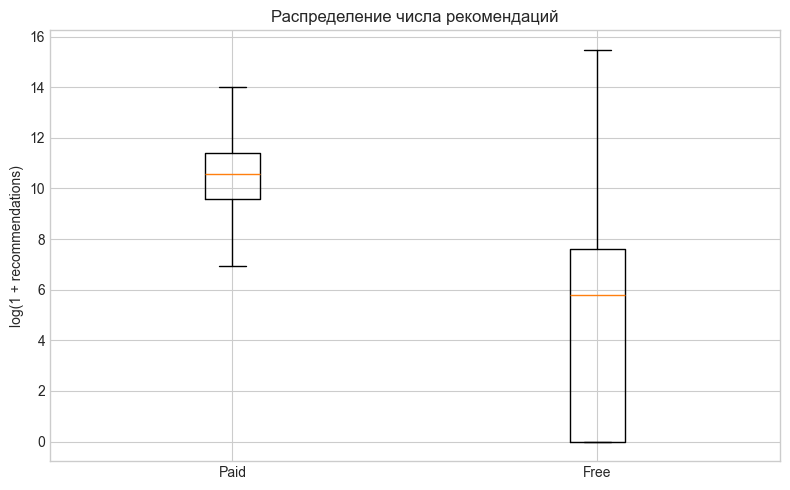

In [18]:
groups = []
labels = []
for is_free, label in [(False, 'Paid'), (True, 'Free')]:
    values = recommendation_sample.loc[
        recommendation_sample['is_free'].eq(is_free), 'recommendations'
    ]
    if len(values):
        groups.append(np.log1p(values))
        labels.append(label)

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(groups, tick_labels=labels, showfliers=False)
ax.set_title('Распределение числа рекомендаций')
ax.set_ylabel('log(1 + recommendations)')
fig.tight_layout()
fig.savefig(IMAGES_DIR / 'recommendations_free_vs_paid.png', dpi=160)
plt.show()

In [19]:
def bootstrap_median_difference(first, second, iterations=5_000, seed=42):
    # Bootstrap CI for median(first) - median(second).
    first = np.asarray(first.dropna())
    second = np.asarray(second.dropna())
    if len(first) == 0 or len(second) == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(seed)
    differences = np.empty(iterations)
    for index in range(iterations):
        first_sample = rng.choice(first, size=len(first), replace=True)
        second_sample = rng.choice(second, size=len(second), replace=True)
        differences[index] = np.median(first_sample) - np.median(second_sample)

    observed = np.median(first) - np.median(second)
    low, high = np.quantile(differences, [0.025, 0.975])
    return observed, low, high


free_values = recommendation_sample.loc[
    recommendation_sample['is_free'].eq(True), 'recommendations'
]
paid_values = recommendation_sample.loc[
    recommendation_sample['is_free'].eq(False), 'recommendations'
]

median_difference, ci_low, ci_high = bootstrap_median_difference(
    free_values, paid_values
)
pd.Series({
    'free_minus_paid_median': median_difference,
    'bootstrap_95_ci_low': ci_low,
    'bootstrap_95_ci_high': ci_high,
}).round(1)


free_minus_paid_median   -38462.0
bootstrap_95_ci_low      -44837.9
bootstrap_95_ci_high     -33195.0
dtype: float64

### Вопрос 2. Free-to-play и платные игры внутри периодов релиза

Поскольку `recommendations` накапливается со временем, общее сравнение дополняется стратификацией по периоду релиза. Это не полностью устраняет смешивающие факторы, но делает интерпретацию аккуратнее, чем сравнение всех старых и новых игр в одной группе.


In [20]:
release_bins = [0, 2014, 2019, 2023, np.inf]
release_labels = ['≤2014', '2015–2019', '2020–2023', '2024+']

recommendations_by_period = (
    df_released.loc[df_released['recommendations'].notna()]
    .assign(
        release_period=lambda x: pd.cut(
            x['release_year'], bins=release_bins, labels=release_labels,
        ),
        model=lambda x: x['is_free'].map({True: 'Free', False: 'Paid'}),
    )
    .groupby(['release_period', 'model'], observed=True)['recommendations']
    .agg(games='count', median='median')
    .reset_index()
)
recommendations_by_period

,release_period,model,games,median
0,≤2014,Free,35,295.0
1,≤2014,Paid,242,21951.5
2,2015–2019,Free,64,429.0
3,2015–2019,Paid,289,39409.0
4,2020–2023,Free,32,178.5
5,2020–2023,Paid,172,57943.0
6,2024+,Free,6,369.5
7,2024+,Paid,54,84815.0


### Вопрос 3. Цена платных игр в крупных жанрах

Рассматриваются только выпущенные платные игры с подтверждённой ценой в USD. Для устойчивости исключаются жанры, где меньше 10 игр. Медиана предпочтительнее среднего при асимметричных ценах. Одна игра может относиться к нескольким жанрам, поэтому группы не являются взаимоисключающими.


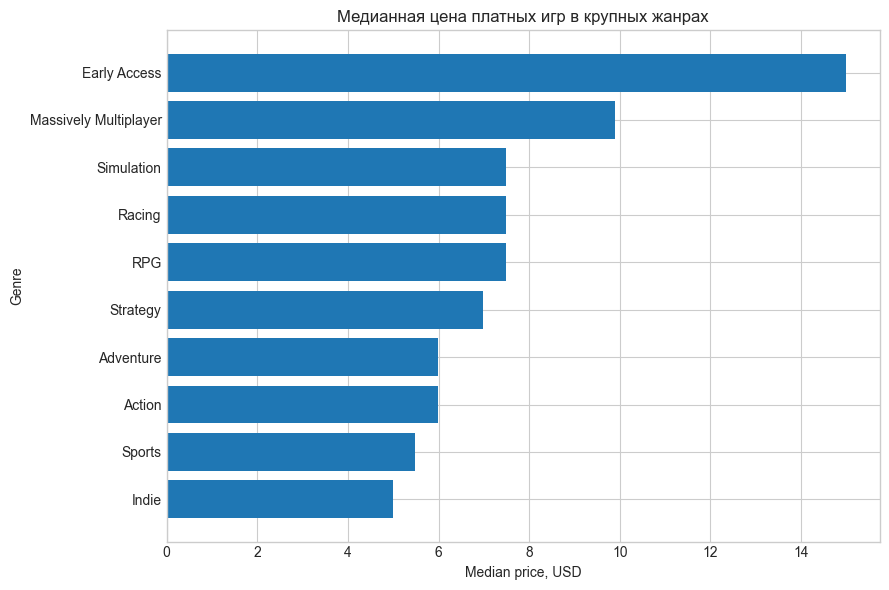

In [21]:
genre_price_plot = median_price_by_genre_sql.head(10).sort_values('median_price_usd')

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(genre_price_plot['genre_name'], genre_price_plot['median_price_usd'])
ax.set_title('Медианная цена платных игр в крупных жанрах')
ax.set_xlabel('Median price, USD')
ax.set_ylabel('Genre')
fig.tight_layout()
fig.savefig(IMAGES_DIR / 'median_price_by_genre.png', dpi=160)
plt.show()

### Дополнительный анализ. Связь цены и числа рекомендаций

Pearson-корреляция исходных значений чувствительна к выбросам и предполагает линейную связь. Здесь используется ранговая корреляция Спирмена, вычисленная как корреляция рангов. Для визуализации обе оси преобразуются через `log1p`; данные не удаляются произвольным порогом вроде «цена ≤ 100».


In [22]:
price_recommendation_sample = df_analysis.loc[
    df_analysis['is_free'].eq(False)
    & df_analysis['price_usd'].notna()
    & df_analysis['price_currency'].eq('USD')
    & df_analysis['recommendations'].notna(),
    ['price_usd', 'recommendations', 'release_year'],
].copy()

spearman_rho = (
    price_recommendation_sample['price_usd'].rank(method='average')
    .corr(price_recommendation_sample['recommendations'].rank(method='average'))
)

pd.Series({
    'paid_games_in_analysis': len(price_recommendation_sample),
    'spearman_rho': spearman_rho,
}).round(3)

paid_games_in_analysis    672.000
spearman_rho                0.362
dtype: float64

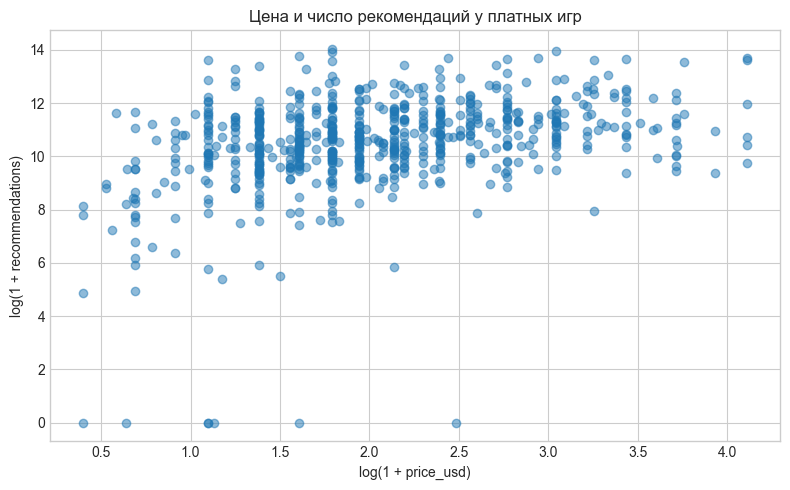

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    np.log1p(price_recommendation_sample['price_usd']),
    np.log1p(price_recommendation_sample['recommendations']),
    alpha=0.5,
)
ax.set_title('Цена и число рекомендаций у платных игр')
ax.set_xlabel('log(1 + price_usd)')
ax.set_ylabel('log(1 + recommendations)')
fig.tight_layout()
fig.savefig(IMAGES_DIR / 'price_vs_recommendations.png', dpi=160)
plt.show()

In [24]:
correlation_by_period_sample = price_recommendation_sample.dropna(
    subset=['release_year']
).copy()
correlation_by_period_sample['release_period'] = pd.cut(
    correlation_by_period_sample['release_year'],
    bins=release_bins,
    labels=release_labels,
)

correlation_by_period = []
for period, group in correlation_by_period_sample.groupby('release_period', observed=True):
    if len(group) < 10:
        continue
    rho = group['price_usd'].rank().corr(group['recommendations'].rank())
    correlation_by_period.append({
        'release_period': period,
        'games': len(group),
        'spearman_rho': rho,
    })

pd.DataFrame(correlation_by_period).round(3)

,release_period,games,spearman_rho
0,≤2014,215,0.132
1,2015–2019,247,0.383
2,2020–2023,154,0.292
3,2024+,53,0.016


## 8. Итоги

Следующая ячейка формирует краткий итог из фактически рассчитанных показателей. Числа не зашиты в текст заранее: после обновления snapshot вывод обновится вместе с анализом.


In [25]:
free_median = recommendation_stats.loc['Free', 'median']
paid_median = recommendation_stats.loc['Paid', 'median']

period_pivot = recommendations_by_period.pivot(
    index='release_period', columns='model', values='median'
).dropna(subset=['Free', 'Paid'], how='any')
period_pivot['free_minus_paid'] = period_pivot['Free'] - period_pivot['Paid']
largest_period = period_pivot['free_minus_paid'].abs().idxmax()
largest_gap = period_pivot.loc[largest_period, 'free_minus_paid']
higher_model = 'free-to-play' if largest_gap > 0 else 'платных игр'

highest_price_genre = median_price_by_genre_sql.iloc[0]
summary = f'''
### Краткий результат

- Подготовленный snapshot содержит **{len(df_clean)}** уникальных игр.
- Медиана рекомендаций: **{free_median:,.0f}** у free-to-play и **{paid_median:,.0f}** у платных игр. Это описательное сравнение, а не эффект модели монетизации.
- Наибольшее различие медиан внутри периодов релиза наблюдается в группе **{largest_period}**: медиана выше у {higher_model} на **{abs(largest_gap):,.0f}**. Разбиение по времени лишь частично учитывает возраст игры.
- Среди жанров минимум с 10 платными играми самая высокая медианная цена у **{highest_price_genre['genre_name']}** (${highest_price_genre['median_price_usd']:.2f}).
- Ранговая корреляция подтверждённой USD-цены и рекомендаций среди платных игр: **ρ = {spearman_rho:.3f}**. Это умеренная положительная связь, но не причинный эффект.
'''
display(Markdown(summary))


### Краткий результат

- Подготовленный snapshot содержит **906** уникальных игр.
- Медиана рекомендаций: **328** у free-to-play и **38,790** у платных игр. Это описательное сравнение, а не эффект модели монетизации.
- Наибольшее различие медиан внутри периодов релиза наблюдается в группе **2024+**: медиана выше у платных игр на **84,446**. Разбиение по времени лишь частично учитывает возраст игры.
- Среди жанров минимум с 10 платными играми самая высокая медианная цена у **Early Access** ($14.99).
- Ранговая корреляция подтверждённой USD-цены и рекомендаций среди платных игр: **ρ = 0.362**. Это умеренная положительная связь, но не причинный эффект.


### Ограничения и следующие шаги

1. Выборка смещена к популярным играм SteamSpy и не репрезентативна для всего Steam.
2. Метаданные/рекомендации и цены относятся к разным моментам времени; сопоставление не является единым синхронным snapshot.
3. Число рекомендаций накапливается со временем; стратификация по периоду релиза лишь частично учитывает возраст игры.
4. Текущая цена зависит от региона и момента проверки, может отражать скидку и недоступна для части платных игр.
5. Жанры пересекаются: одна игра участвует в нескольких жанровых группах.
6. В данных нет продаж, выручки, маркетинговых расходов и истории изменения цен.

Для развития проекта полезно собирать синхронные snapshots по расписанию и моделировать изменение рекомендаций с контролем возраста игры и жанра.

### Что демонстрирует проект

- работа с двумя API и локальным кэшем для воспроизводимости;
- аудит обычных и скрытых пропусков, дублей, типов и дат;
- строгая фильтрация цены по подтверждённой валюте USD;
- нормализация many-to-many данных в SQLite с ключами и проверкой связей;
- SQL с `JOIN`, агрегацией, CTE и оконными функциями;
- описательный анализ, bootstrap-интервал, временная стратификация и честные ограничения.